# First Project - Data Analysis
This project is centered around exploratory data analysis techniques and presentation of results to a client.

# Column Names and descriptions for King County Data Set:

Data Set is represented in PostgreSQL Database with these columns and their meaning:

- **id** - unique identified for a house
- **dateDate** - house was sold
- **pricePrice** - is prediction target
- **bedroomsNumber** - # of bedrooms
- **bathroomsNumber** - # of bathrooms
- **sqft_livingsquare** - footage of the home
- **sqft_lotsquare** - footage of the lot
- **floorsTotal** - floors (levels) in house
- **waterfront** - House which has a view to a waterfront
- **view** - quality of view
- **condition** - How good the condition is ( Overall )
- **grade** - overall grade given to the housing unit, based on King County grading system
- **sqft_above** - square footage of house apart from basement
- **sqft_basement** - square footage of the basement
- **yr_built** - Built Year
- **yr_renovated** - Year when house was renovated
- **zipcode** - zip
- **lat** - Latitude coordinate
- **long** - Longitude coordinate
- **sqft_living15** - The square footage of interior housing living space for the nearest 15 neighbors
- **sqft_lot15** - The square footage of the land lots of the nearest 15 neighbors

# Chosen Client:
- Name: Jennifer Montgomery
- Type: Buyer
- Requirements:
    - High budget,
    - Wants to show off, 
    - Timing within a month,
    - Waterfront, 
    - Renovated, 
    - High grades, 
    - Resell within 1 year.



# Step 1 - Load Data Set from CSV file

This is initial step for this EDA project.
Here I load the data set from an eda.csv file to the DataFrame from Pandas.

But I will start with importing the needed to this Project Python modules.

In [1]:
import warnings
import folium
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from utils.cartesian_interpolation import interpolate_waterfront_cartesian # custom function to interpolate waterfront properties

warnings.filterwarnings("ignore")

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


Now I will read the data set from csv file and store it in a pandas DataFrame.

In [2]:
df_eda = pd.read_csv('data/eda.csv')

These initial steps will setup my Jupyter Notebook for performing other EDA Project steps.

# Step 2 - Understanding Loaded Data Set

Here I will call special Pandas functions on the loaded DataFrame to get the important information about the DataFrame columns, their data types, number of NaN values, etc.

In [3]:
df_eda.info() # To get a concise summary of the DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              21597 non-null  int64  
 1   house_id        21597 non-null  int64  
 2   date            21597 non-null  str    
 3   price           21597 non-null  float64
 4   condition       21597 non-null  int64  
 5   view            21534 non-null  float64
 6   bathrooms       21597 non-null  float64
 7   bedrooms        21597 non-null  float64
 8   floors          21597 non-null  float64
 9   grade           21597 non-null  int64  
 10  latitude        21597 non-null  float64
 11  longitude       21597 non-null  float64
 12  sqft_above      21597 non-null  float64
 13  sqft_basement   21143 non-null  float64
 14  sqft_living     21597 non-null  float64
 15  sqft_living15   21597 non-null  float64
 16  sqft_lot        21597 non-null  float64
 17  sqft_lot15      21597 non-null  float64
 1

In [4]:
df_eda.describe() # To get statistical summary of numerical columns

,id,house_id,price,condition,view,bathrooms,bedrooms,floors,grade,latitude,...,sqft_above,sqft_basement,sqft_living,sqft_living15,sqft_lot,sqft_lot15,waterfront,year_built,year_renovated,zipcode
count,21597.000000,2.159700e+04,2.159700e+04,21597.000000,21534.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,...,21597.000000,21143.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19221.000000,21597.000000,17755.000000,21597.000000
mean,10799.000000,4.580474e+09,5.402966e+05,3.409825,0.233863,2.115826,3.373200,1.494096,7.657915,47.560093,...,1788.596842,291.851724,2080.321850,1986.620318,1.509941e+04,12758.283512,0.007596,1970.999676,836.367784,98077.951845
std,6234.661218,2.876736e+09,3.673681e+05,0.650546,0.765686,0.768984,0.926299,0.539683,1.173200,0.138552,...,827.759761,442.498337,918.106125,685.230472,4.141264e+04,27274.441950,0.086825,29.375234,3999.464139,53.513072
min,1.000000,1.000102e+06,7.800000e+04,1.000000,0.000000,0.500000,1.000000,1.000000,3.000000,47.155900,...,370.000000,0.000000,370.000000,399.000000,5.200000e+02,651.000000,0.000000,1900.000000,0.000000,98001.000000
25%,5400.000000,2.123049e+09,3.220000e+05,3.000000,0.000000,1.750000,3.000000,1.000000,7.000000,47.471100,...,1190.000000,0.000000,1430.000000,1490.000000,5.040000e+03,5100.000000,0.000000,1951.000000,0.000000,98033.000000
50%,10799.000000,3.904930e+09,4.500000e+05,3.000000,0.000000,2.250000,3.000000,1.500000,7.000000,47.571800,...,1560.000000,0.000000,1910.000000,1840.000000,7.618000e+03,7620.000000,0.000000,1975.000000,0.000000,98065.000000
75%,16198.000000,7.308900e+09,6.450000e+05,4.000000,0.000000,2.500000,4.000000,2.000000,8.000000,47.678000,...,2210.000000,560.000000,2550.000000,2360.000000,1.068500e+04,10083.000000,0.000000,1997.000000,0.000000,98118.000000
max,21597.000000,9.900000e+09,7.700000e+06,5.000000,4.000000,8.000000,33.000000,3.500000,13.000000,47.777600,...,9410.000000,4820.000000,13540.000000,6210.000000,1.651359e+06,871200.000000,1.000000,2015.000000,20150.000000,98199.000000


In [5]:
df_eda.isna().sum().sort_values(ascending=False) # To see the number of NaN values in each column

year_renovated    3842
waterfront        2376
sqft_basement      454
view                63
house_id             0
id                   0
condition            0
price                0
date                 0
bathrooms            0
grade                0
latitude             0
floors               0
bedrooms             0
sqft_above           0
longitude            0
sqft_living          0
sqft_living15        0
sqft_lot15           0
sqft_lot             0
year_built           0
zipcode              0
dtype: int64

In [6]:
df_eda.head(10) # To see the first 10 rows of the DataFrame

,id,house_id,date,price,condition,view,bathrooms,bedrooms,floors,grade,...,sqft_above,sqft_basement,sqft_living,sqft_living15,sqft_lot,sqft_lot15,waterfront,year_built,year_renovated,zipcode
0,1,7129300520,2014-10-13,221900.0,3,0.0,1.00,3.0,1.0,7,...,1180.0,0.0,1180.0,1340.0,5650.0,5650.0,NaN,1955,0.0,98178
1,2,6414100192,2014-12-09,538000.0,3,0.0,2.25,3.0,2.0,7,...,2170.0,400.0,2570.0,1690.0,7242.0,7639.0,0.0,1951,19910.0,98125
2,3,5631500400,2015-02-25,180000.0,3,0.0,1.00,2.0,1.0,6,...,770.0,0.0,770.0,2720.0,10000.0,8062.0,0.0,1933,NaN,98028
3,4,2487200875,2014-12-09,604000.0,5,0.0,3.00,4.0,1.0,7,...,1050.0,910.0,1960.0,1360.0,5000.0,5000.0,0.0,1965,0.0,98136
4,5,1954400510,2015-02-18,510000.0,3,0.0,2.00,3.0,1.0,8,...,1680.0,0.0,1680.0,1800.0,8080.0,7503.0,0.0,1987,0.0,98074
5,6,7237550310,2014-05-12,1230000.0,3,0.0,4.50,4.0,1.0,11,...,3890.0,1530.0,5420.0,4760.0,101930.0,101930.0,0.0,2001,0.0,98053
6,7,1321400060,2014-06-27,257500.0,3,0.0,2.25,3.0,2.0,7,...,1715.0,NaN,1715.0,2238.0,6819.0,6819.0,0.0,1995,0.0,98003
7,8,2008000270,2015-01-15,291850.0,3,NaN,1.50,3.0,1.0,7,...,1060.0,0.0,1060.0,1650.0,9711.0,9711.0,0.0,1963,0.0,98198
8,9,2414600126,2015-04-15,229500.0,3,0.0,1.00,3.0,1.0,7,...,1050.0,730.0,1780.0,1780.0,7470.0,8113.0,0.0,1960,0.0,98146
9,10,3793500160,2015-03-12,323000.0,3,0.0,2.50,3.0,2.0,7,...,1890.0,0.0,1890.0,2390.0,6560.0,7570.0,0.0,2003,0.0,98038


# Step 3 - Hypotheses

After closely reviewing the current dataset and examining the structure and contents of several columns, I’ve identified a number of hypotheses that I plan to validate—or reject—during the exploratory data analysis (EDA) phase.

## Proposed Hypotheses

Considering my client’s requirements and the current state of the dataset, I propose the following hypotheses:

1) Missing Waterfront Data Hypothesis:
    - Hypothesis: The 11% of records with missing waterfront data are not missing at random; they are likely concentrated among non-waterfront properties.
    - Rationale: Data collectors may have omitted the waterfront field when it was an obvious “no,” leading to systematic missingness.
    - Test: Compare price distributions and property features between records with missing waterfront data and those with known waterfront status.

2) Missing Year Renovated Data Hypothesis:
    - Hypothesis: Properties missing the year_renovated value are more likely to have never been renovated.
    - Rationale: Renovations are typically highlighted by owners or sellers; missing data likely implies no renovation.
    - Test: Compare property age, condition, and prices between records with missing renovation data and those with year_renovated = 0.

3) Waterfront Price Premium Hypothesis:
    - Hypothesis: Waterfront properties command a significant price premium over non-waterfront homes.
    - Rationale: Waterfront access is a scarce and highly desirable amenity, driving higher prices.
    - Test: Compare median and mean sale prices between waterfront = 1 and waterfront = 0 properties.

4) Living Area and Price Relationship Hypothesis:
    - Hypothesis: Home prices increase non-linearly with living area, with larger homes showing disproportionately higher price premiums.
    - Rationale: Bigger living areas typically add value, but premium pricing often accelerates for luxury-sized homes due to increased demand and exclusivity.
    - Test: Perform regression analysis of price against living area and examine whether price increases accelerate for larger homes.

5) Renovation Effect on Price Hypothesis:
    - Hypothesis: Renovated properties (year_renovated > 0) sell at higher prices than comparable non-renovated properties of the same age.
    - Rationale: Renovations add value and appeal to buyers with higher budgets.
    - Test: Control for year_built and compare prices between renovated and non-renovated homes.

6) Luxury Price Seasonality Hypothesis:
    - Hypothesis: Luxury properties (priced at or above the 90th percentile) exhibit seasonal price patterns, with peak prices occurring in January.
    - Rationale: Factors like year-end financial planning and bonuses may drive increased luxury purchases early in the year.
    - Test: Perform monthly time-series analysis of luxury segment prices.

7) Sales Volume and Price Inverse Relationship Hypothesis:
    - Hypothesis: Higher monthly sales volumes correspond to lower median sale prices.
    - Rationale: Increased supply or high transaction activity can create downward pressure on prices due to supply-demand dynamics.
    - Test: Analyze the correlation between monthly sales counts and median prices.

# Step 4 - Correlation Matrix

To better understand the relationships between dataset columns, it is very useful to create a correlation plot.
Studying this visualization will make it easier to analyze the data and develop or refine hypotheses.

### Correlation Heatmap Analysis

This heatmap shows correlations between all numeric features, helping to:
- Identify which features most strongly predict price
- Detect multicollinearity (highly correlated features)
- Understand feature relationships

**Reading the heatmap:**
- Red = positive correlation
- Blue = negative correlation
- Darker colors = stronger correlation

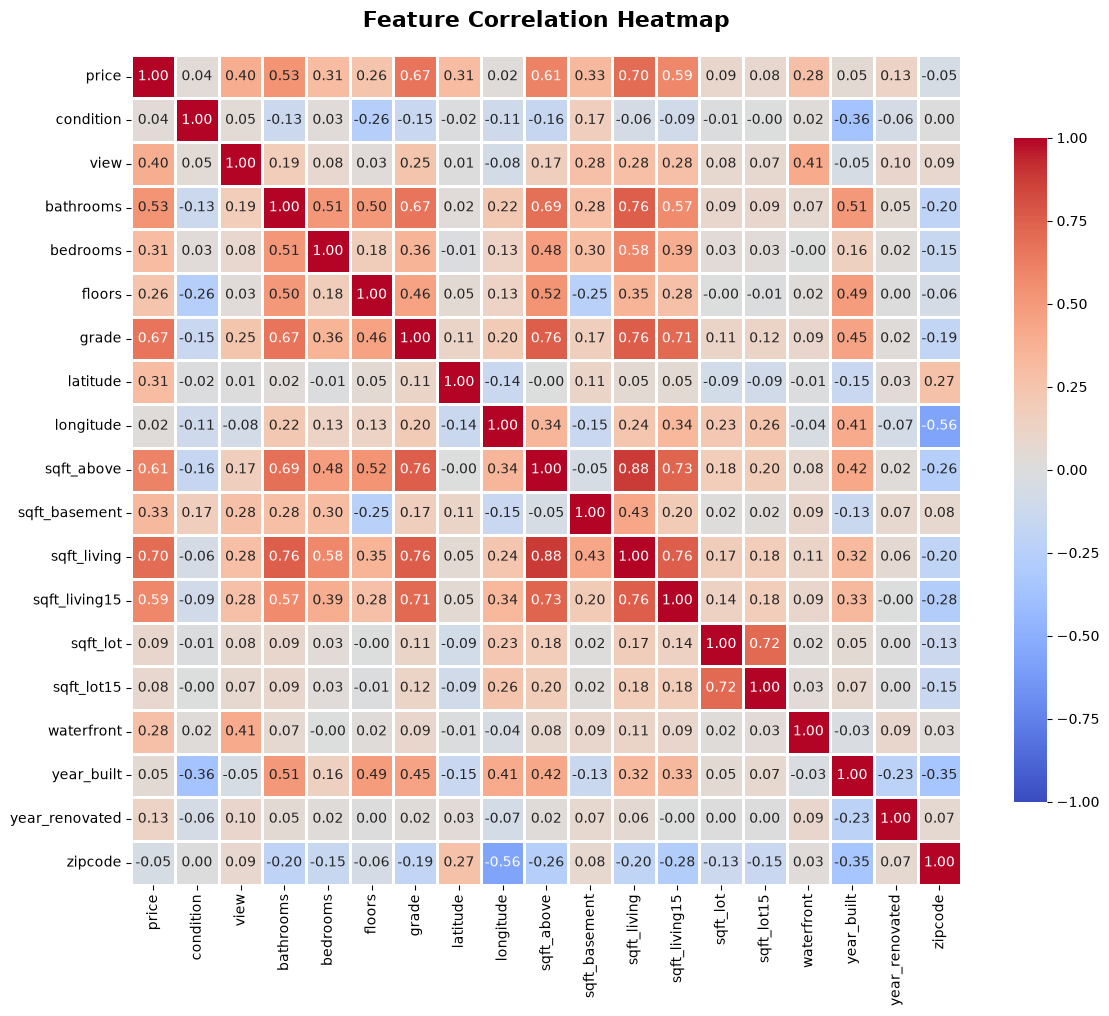

In [7]:
# Select numeric columns for correlation analysis
numeric_cols = ['price', 'condition', 'view', 'bathrooms',
       'bedrooms', 'floors', 'grade', 'latitude', 'longitude', 'sqft_above',
       'sqft_basement', 'sqft_living', 'sqft_living15', 'sqft_lot',
       'sqft_lot15', 'waterfront', 'year_built', 'year_renovated', 'zipcode']

# Calculate correlation matrix
corr_matrix = df_eda[numeric_cols].corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Key findings from this plot:

📊 Strongest Positive Correlations with Price:
   1. sqft_living: 0.702
   2. grade: 0.668
   3. sqft_above: 0.605
   4. sqft_living15: 0.585
   5. bathrooms: 0.526

✅ These results can be used to further check the hypotheses and dataset.

# Step 5 - Working with Missing Data

Before diving deeper into the data analysis, I will first focus on two key columns—year_renovated and waterfront—which contain missing values and are especially important based on the client’s requirements.
My goal is to validate hypotheses H1 and H2 related to these critical fields.

### Missing Waterfront Data Hypothesis:

Start with data manipulations to prove this hypotheses:

In [8]:
# Calculate missing data stats
total_records = len(df_eda)
waterfront_nan = df_eda['waterfront'].isna().sum()
waterfront_0 = (df_eda['waterfront'] == 0).sum()
waterfront_1 = (df_eda['waterfront'] == 1).sum()

print(f"\nMissing Data Statistics:")
print(f"  Total records: {total_records:,}")
print(f"  Waterfront NaN: {waterfront_nan:,} ({waterfront_nan/total_records*100:.2f}%)")
print(f"  Waterfront = 0: {waterfront_0:,} ({waterfront_0/total_records*100:.2f}%)")
print(f"  Waterfront = 1: {waterfront_1:,} ({waterfront_1/total_records*100:.2f}%)")

# Price comparison
price_nan = df_eda[df_eda['waterfront'].isna()]['price']
price_wf0 = df_eda[df_eda['waterfront'] == 0]['price']
price_wf1 = df_eda[df_eda['waterfront'] == 1]['price']

print(f"\nPrice Comparison:")
print(f"  NaN waterfront - Median: ${price_nan.median():,.0f}, Mean: ${price_nan.mean():,.0f}")
print(f"  Waterfront = 0 - Median: ${price_wf0.median():,.0f}, Mean: ${price_wf0.mean():,.0f}")
print(f"  Waterfront = 1 - Median: ${price_wf1.median():,.0f}, Mean: ${price_wf1.mean():,.0f}")

# Statistical test: Compare NaN prices to wf=0 and wf=1
diff_to_wf0 = abs(price_nan.median() - price_wf0.median())
diff_to_wf1 = abs(price_nan.median() - price_wf1.median())

print(f"\nPrice Difference Analysis:")
print(f"  |NaN median - WF=0 median|: ${diff_to_wf0:,.0f}")
print(f"  |NaN median - WF=1 median|: ${diff_to_wf1:,.0f}")

if diff_to_wf0 < diff_to_wf1:
    print(f"\n✅ CONCLUSION: NaN prices are CLOSER to non-waterfront (WF=0) properties")
    print(f"   This supports H1 - missing data likely represents non-waterfront properties")
else:
    print(f"\n⚠️  CONCLUSION: NaN prices are closer to waterfront (WF=1) properties")
    print(f"   This suggests missing data may be mixed or have different pattern")


Missing Data Statistics:
  Total records: 21,597
  Waterfront NaN: 2,376 (11.00%)
  Waterfront = 0: 19,075 (88.32%)
  Waterfront = 1: 146 (0.68%)

Price Comparison:
  NaN waterfront - Median: $445,000, Mean: $529,430
  Waterfront = 0 - Median: $450,000, Mean: $532,642
  Waterfront = 1 - Median: $1,510,000, Mean: $1,717,215

Price Difference Analysis:
  |NaN median - WF=0 median|: $5,000
  |NaN median - WF=1 median|: $1,065,000

✅ CONCLUSION: NaN prices are CLOSER to non-waterfront (WF=0) properties
   This supports H1 - missing data likely represents non-waterfront properties


Continue with visual confirmation of numerical results:

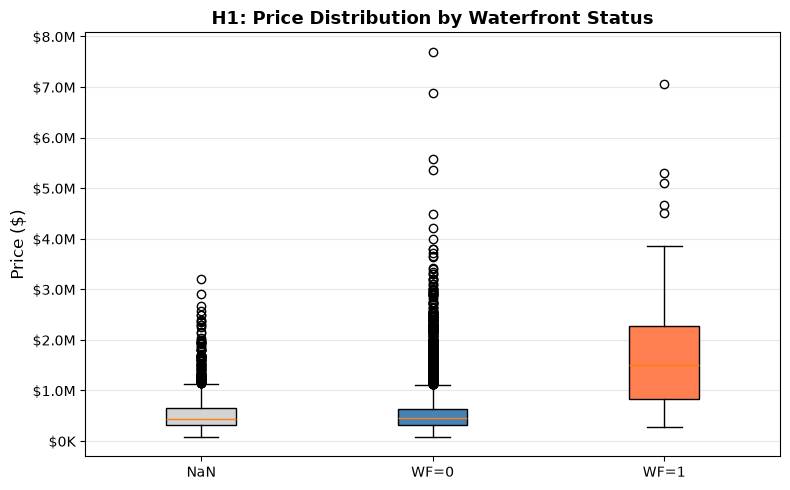

In [9]:
# Visualization: Price distributions by waterfront status
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

# Left plot: Box plots
ax = axes
data_to_plot = [
    df_eda[df_eda['waterfront'].isna()]['price'].dropna(),
    df_eda[df_eda['waterfront'] == 0]['price'].dropna(),
    df_eda[df_eda['waterfront'] == 1]['price'].dropna()
]
# set tick labels separately - boxplot(labels=) was renamed in matplotlib 3.9
bp = ax.boxplot(data_to_plot, patch_artist=True)
ax.set_xticklabels(['NaN', 'WF=0', 'WF=1'])
colors = ['lightgray', 'steelblue', 'coral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel('Price ($)', fontsize=12)
ax.set_title('H1: Price Distribution by Waterfront Status', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
ax.grid(True, alpha=0.3, axis='y')


plt.tight_layout()
plt.show()


### Missing Year Renovated Data Hypothesis:

Start with data manipulations to prove this hypotheses:

In [10]:
# Calculate property age for analysis
df_eda['property_age'] = 2015 - df_eda['year_built']

# Separate groups
renovated_nan = df_eda[df_eda['year_renovated'].isna()]
renovated_0 = df_eda[df_eda['year_renovated'] == 0]
renovated_yes = df_eda[df_eda['year_renovated'] > 0]

print(f"\nMissing Data Statistics:")
print(f"  Year_renovated NaN: {len(renovated_nan):,} ({len(renovated_nan)/len(df_eda)*100:.2f}%)")
print(f"  Year_renovated = 0: {len(renovated_0):,} ({len(renovated_0)/len(df_eda)*100:.2f}%)")
print(f"  Year_renovated > 0: {len(renovated_yes):,} ({len(renovated_yes)/len(df_eda)*100:.2f}%)")

print(f"\nPrice Comparison:")
print(f"  NaN renovation - Median: ${renovated_nan['price'].median():,.0f}")
print(f"  Never renovated (0) - Median: ${renovated_0['price'].median():,.0f}")
print(f"  Renovated (>0) - Median: ${renovated_yes['price'].median():,.0f}")

# Similarity test between NaN and year_renovated=0
price_diff_pct = abs(renovated_nan['price'].median() - renovated_0['price'].median()) / renovated_0['price'].median() * 100

print(f"\nSimilarity Analysis (NaN vs year_renovated=0):")
print(f"  Price difference: {price_diff_pct:.1f}%")

if price_diff_pct < 10:
    print(f"\n✅ CONCLUSION: NaN values are VERY SIMILAR to year_renovated=0")
    print(f"   This supports H2 - missing data likely means 'never renovated'")
    print(f"   RECOMMENDATION: Safe to impute NaN as 0")
else:
    print(f"\n⚠️  CONCLUSION: NaN values differ from year_renovated=0")
    print(f"   Consider more careful imputation or keep NaN separate")


Missing Data Statistics:
  Year_renovated NaN: 3,842 (17.79%)
  Year_renovated = 0: 17,011 (78.77%)
  Year_renovated > 0: 744 (3.44%)

Price Comparison:
  NaN renovation - Median: $450,000
  Never renovated (0) - Median: $447,500
  Renovated (>0) - Median: $607,502

Similarity Analysis (NaN vs year_renovated=0):
  Price difference: 0.6%

✅ CONCLUSION: NaN values are VERY SIMILAR to year_renovated=0
   This supports H2 - missing data likely means 'never renovated'
   RECOMMENDATION: Safe to impute NaN as 0


Continue with visual representation of numerical calculations:

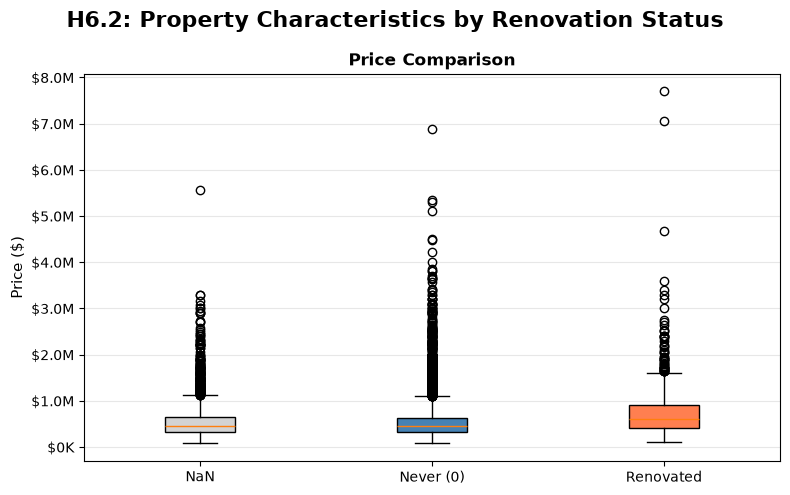

In [11]:
# Visualization: Property characteristics by renovation status
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle('H6.2: Property Characteristics by Renovation Status', fontsize=16, fontweight='bold')

ax = axes
data_price = [
    renovated_nan['price'].dropna(),
    renovated_0['price'].dropna(),
    renovated_yes['price'].dropna()
]
# set tick labels separately - boxplot(labels=) was renamed in matplotlib 3.9
bp = ax.boxplot(data_price, patch_artist=True)
ax.set_xticklabels(['NaN', 'Never (0)', 'Renovated'])
for patch, color in zip(bp['boxes'], ['lightgray', 'steelblue', 'coral']):
    patch.set_facecolor(color)
ax.set_ylabel('Price ($)', fontsize=11)
ax.set_title('Price Comparison', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
ax.grid(True, alpha=0.3, axis='y')


plt.tight_layout()
plt.show()

### Missing Data Hypotheses - Summary

Based on the analyses above:

**H1 (Waterfront):** 
- If NaN prices are similar to waterfront=0, missing data likely represents non-waterfront properties
- Decision: Can impute using price-based or geographic methods

**H2 (Year Renovated):**
- If NaN properties are similar to year_renovated=0 in age, condition, and price, missing data likely means 'never renovated'
- Decision: Safe to impute NaN as 0 if similarity is high

These findings guide my data cleaning decisions in the next section.

# Step 6 - Data Cleaning

In this step, I will implement the assumptions made previously by replacing missing values in the year_renovated and waterfront columns. Additionally, I will correct data types and ensure proper data representation across several columns.

1) Convert 'date' column to Timestemp type:

In [12]:
df_eda['date'] = pd.to_datetime(df_eda['date']) # Convert 'date' column to datetime type
print(f"Check date type: {type(df_eda['date'].iloc[0])}") # To verify the data type of date column

Check date type: <class 'pandas.Timestamp'>


2) Change data represented in 'year_renovated' column, because year format is wrong:

In [13]:
# The source column stores the year multiplied by 10 (e.g. 1991 -> 19910).
# Track which rows were unknown BEFORE imputing - needed for the sensitivity
# check in Step 8, because "unknown" is not the same claim as "never renovated".
df_eda['renovation_unknown'] = df_eda['year_renovated'].isna()

# Divide by 10 to recover the real year. Numeric, so it is dtype-safe on a
# re-run - the previous string-slicing version silently produced 19910 on a
# fresh kernel and only gave 1991 when the cell was executed twice.
df_eda['year_renovated'] = (
    (df_eda['year_renovated'] // 10)
    .fillna(0)                # H2: missing renovation year means "never renovated"
    .astype('Int64')
)

assert df_eda['year_renovated'].between(0, 2015).all(), "year_renovated out of range"
print(f"Renovation years present: {sorted(df_eda['year_renovated'].unique())[:5]} ... "
      f"{sorted(df_eda['year_renovated'].unique())[-3:]}")
print(f"Rows with unknown renovation status (imputed as 0): {df_eda['renovation_unknown'].sum():,}")
df_eda['year_renovated'].head()

Renovation years present: [np.int64(0), np.int64(1934), np.int64(1940), np.int64(1944), np.int64(1945)] ... [np.int64(2013), np.int64(2014), np.int64(2015)]
Rows with unknown renovation status (imputed as 0): 3,842


0       0
1    1991
2       0
3       0
4       0
Name: year_renovated, dtype: Int64

In this code, I not only remove trailing zeros from the year values but also apply Hypothesis 1 by replacing all NaN values with 0.

3) Apply modifications to 'waterfront' column:

I chose to use the Geo-Euclidean distance method to replace NaN values in this column. Missing values are interpolated based on neighboring houses—assigning 1 if nearby properties have waterfront access, and 0 if they do not.

In [14]:
print(f'Unique waterfront values: {df_eda["waterfront"].unique()}') # To see unique values in waterfront column

df_eda['waterfront'] = df_eda['waterfront'].astype('Int64') # Convert waterfront to integer type
print(f"Check waterfront type: {type(df_eda['waterfront'].iloc[0])}") # To verify the data type of waterfront column

# from the hypotheses analysis - waterfront missing data likely means non-waterfront (from prices)
df_eda = interpolate_waterfront_cartesian(df_eda) # To interpolate missing waterfront values


Unique waterfront values: [nan  0.  1.]
Check waterfront type: <class 'pandas.api.typing.NAType'>

Known waterfront: 19221
Unknown waterfront: 2376



Imputation complete!
Imputed as waterfront=1: 3
Imputed as waterfront=0: 2373


> **Caveat on the waterfront imputation.** Because only ~0.7% of properties are
> waterfront, a majority vote among neighbours is heavily biased toward `0`, and a
> headline "accuracy" figure would be meaningless at that base rate. The function
> recovers only a small minority of genuinely-waterfront properties and produces
> the occasional false positive. It is also a Euclidean distance on raw degrees, so
> at latitude 47.5 deg the "165 m radius" is really an ellipse about 1.5x wider in
> latitude than in longitude. It is retained here because it is defensible and
> transparent, not because it is accurate - a haversine distance plus a
> distance-to-coastline feature would be the correct upgrade.

After applying these assumptions and data cleaning techniques, the resulting dataset has the following count of missing (NaN) values:

In [15]:
print(df_eda.isna().sum().sort_values(ascending=False)) # To see the count of NaN values after imputation

sqft_basement         454
view                   63
date                    0
id                      0
price                   0
condition               0
bathrooms               0
house_id                0
bedrooms                0
floors                  0
latitude                0
grade                   0
longitude               0
sqft_above              0
sqft_living             0
sqft_living15           0
sqft_lot                0
sqft_lot15              0
waterfront              0
year_built              0
year_renovated          0
zipcode                 0
property_age            0
renovation_unknown      0
dtype: int64


# Step 7 - Hypotheses Investigation and Visualization

This is a major part of the EDA project, where I will conduct a deeper investigation of the dataset to evaluate the validity of my selected hypotheses.

### H3 - Waterfront

✅ Executive dashboard saved as 'images/waterfront_price_dependence.png'


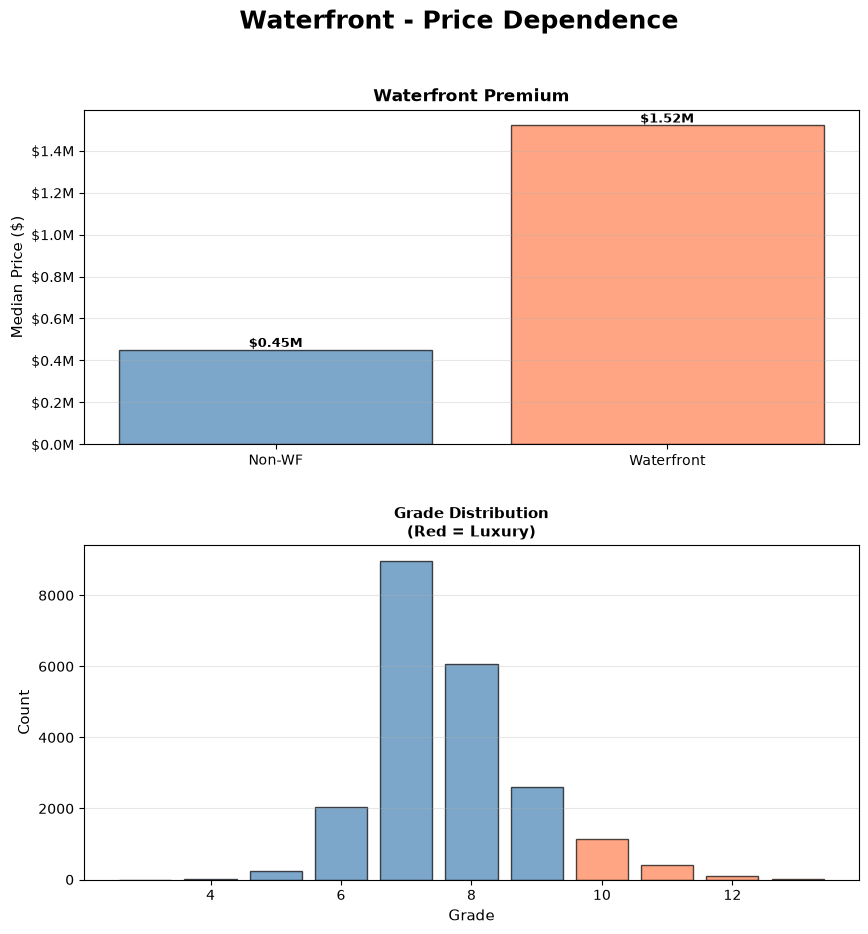

In [16]:
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 1, hspace=0.3, wspace=0.3)
fig.suptitle('Waterfront - Price Dependence', fontsize=18, fontweight='bold')

# Waterfront premium
ax1 = fig.add_subplot(gs[0, 0])
wf_data = df_eda.groupby('waterfront')['price'].median()
wf_labels = ['Non-WF', 'Waterfront']
wf_values = [wf_data.get(0, 0), wf_data.get(1, 0)]
bars = ax1.bar(wf_labels, wf_values,
        color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
ax1.set_ylabel('Median Price ($)', fontsize=11)
ax1.set_title('Waterfront Premium', fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax1.grid(True, alpha=0.3, axis='y')
# Add value labels
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'${height/1e6:.2f}M', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Grade distribution
ax2 = fig.add_subplot(gs[1, 0])
grade_counts = df_eda['grade'].value_counts().sort_index()
colors_grade = ['coral' if g >= 10 else 'steelblue' for g in grade_counts.index]
ax2.bar(grade_counts.index, grade_counts.values, color=colors_grade, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Grade', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Grade Distribution\n(Red = Luxury)', fontweight='bold', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.savefig('images/waterfront_price_dependence.png', dpi=300, bbox_inches='tight')
print("✅ Executive dashboard saved as 'images/waterfront_price_dependence.png'")
plt.show()

This plot clearly supports Hypothesis H3, showing that houses with waterfront access have significantly higher prices and grades compared to those without waterfront.

### H5 - Year Renovated

✅ Executive dashboard saved as 'images/renovation_price_dependence.png'


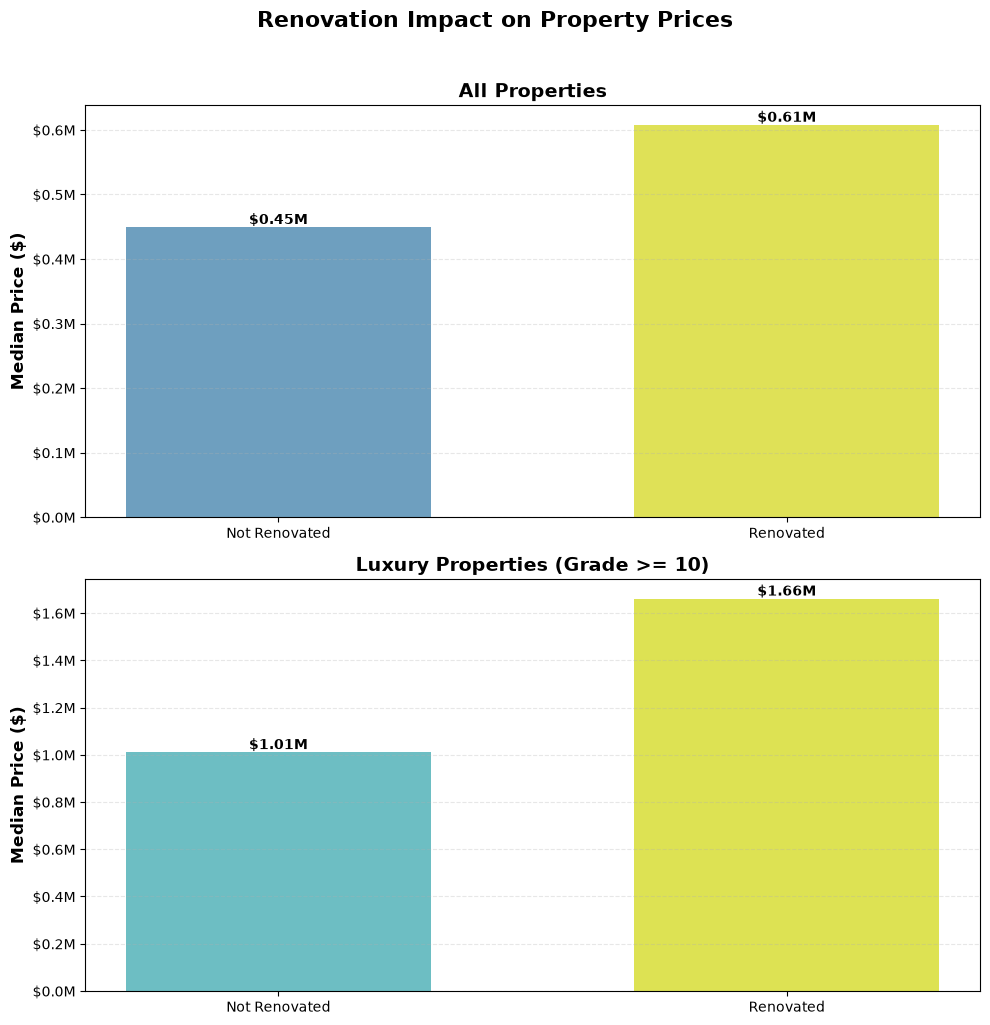


ALL PROPERTIES:
  Not Renovated: $449,000 (n=20,853)
  Renovated:     $607,502 (n=744)
  Premium:       35.3%

LUXURY PROPERTIES (Grade >= 10):
  Not Renovated: $1,010,000 (n=1,576)
  Renovated:     $1,660,000 (n=59)
  Premium:       64.4%

Conclusion: Renovation adds 35.3% value overall, 64.4% in luxury segment - VALIDATED H5


In [17]:
# Create renovation status indicator
df_eda['is_renovated'] = (df_eda['year_renovated'] > 0).astype(int)

# Filter luxury segment for fair comparison
df_luxury = df_eda[df_eda['grade'] >= 10].copy()

# Create figure with 3 subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot 1: Overall market comparison
ax1 = axes[0]
renovation_stats_all = df_eda.groupby('is_renovated')['price'].agg(['median', 'mean', 'count'])
bars1 = ax1.bar([0, 1], renovation_stats_all['median'], color=["#4a87af", "#d7da2d"], alpha=0.8, width=0.6)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Not Renovated', 'Renovated'])
ax1.set_ylabel('Median Price ($)', fontsize=12, fontweight='bold')
ax1.set_title('All Properties', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
for bar, value in zip(bars1, renovation_stats_all['median']):
    ax1.text(bar.get_x() + bar.get_width()/2, value, f'${value/1e6:.2f}M',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Luxury segment comparison
ax2 = axes[1]
renovation_stats_luxury = df_luxury.groupby('is_renovated')['price'].agg(['median', 'mean', 'count'])
bars2 = ax2.bar([0, 1], renovation_stats_luxury['median'], color=["#49aeb5", "#d5db28"], alpha=0.8, width=0.6)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Not Renovated', 'Renovated'])
ax2.set_ylabel('Median Price ($)', fontsize=12, fontweight='bold')
ax2.set_title('Luxury Properties (Grade >= 10)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
for bar, value in zip(bars2, renovation_stats_luxury['median']):
    ax2.text(bar.get_x() + bar.get_width()/2, value, f'${value/1e6:.2f}M',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Renovation Impact on Property Prices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/renovation_price_dependence.png', dpi=300, bbox_inches='tight')
print("✅ Executive dashboard saved as 'images/renovation_price_dependence.png'")
plt.show()

# Print statistics
print("\nALL PROPERTIES:")
median_not_ren = renovation_stats_all.loc[0, 'median']
median_ren = renovation_stats_all.loc[1, 'median']
premium_pct_all = ((median_ren - median_not_ren) / median_not_ren * 100)
print(f"  Not Renovated: ${median_not_ren:,.0f} (n={renovation_stats_all.loc[0, 'count']:,})")
print(f"  Renovated:     ${median_ren:,.0f} (n={renovation_stats_all.loc[1, 'count']:,})")
print(f"  Premium:       {premium_pct_all:.1f}%")

print("\nLUXURY PROPERTIES (Grade >= 10):")
median_not_ren_lux = renovation_stats_luxury.loc[0, 'median']
median_ren_lux = renovation_stats_luxury.loc[1, 'median']
premium_pct_lux = ((median_ren_lux - median_not_ren_lux) / median_not_ren_lux * 100)
print(f"  Not Renovated: ${median_not_ren_lux:,.0f} (n={renovation_stats_luxury.loc[0, 'count']:,})")
print(f"  Renovated:     ${median_ren_lux:,.0f} (n={renovation_stats_luxury.loc[1, 'count']:,})")
print(f"  Premium:       {premium_pct_lux:.1f}%")

print(f"\nConclusion: Renovation adds {premium_pct_all:.1f}% value overall, {premium_pct_lux:.1f}% in luxury segment - VALIDATED H5")

Similar to the previous hypothesis, this plot also demonstrates a significant impact of a building’s renovated status on its price. This relationship is further supported by the correlation plot.

### H4 - Living area and Price

✅ Executive dashboard saved as 'images/price_per_sqft_analysis.png'


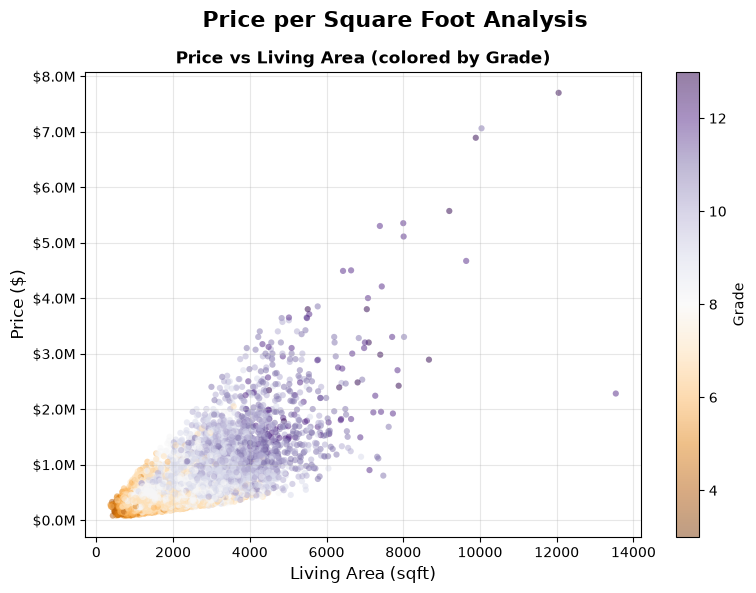


💎 BEST VALUE in Luxury Segment (Grade ≥10, Price ≥75th percentile):
--------------------------------------------------------------------------------
   id    price  sqft_living  price_per_sqft  grade  waterfront  zipcode
 4021 800000.0       7480.0      106.951872     11           0    98166
21035 900000.0       7120.0      126.404494     12           0    98006
18400 784500.0       5820.0      134.793814     11           0    98042
 7274 800000.0       5480.0      145.985401     10           0    98031
20877 790000.0       5370.0      147.113594     10           0    98042

📊 Overall Statistics:
   Median price/sqft (all properties): $245
   Median price/sqft (luxury segment): $304
   Luxury premium: 24%

✅ Bigger luxury homes (large sqft) often have lower price per sqft, even though the total price is high.
 Higher-grade homes (yellow/green points) appear across all sizes but cluster more densely in the upper–middle of the plot,
 showing that grade increases price, but not proportio

In [18]:
# Calculate price per sqft
df_eda['price_per_sqft'] = df_eda['price'] / df_eda['sqft_living']

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle('Price per Square Foot Analysis', fontsize=16, fontweight='bold')

# Plot 2: Scatter - sqft_living vs price colored by grade
ax = axes
scatter = ax.scatter(df_eda['sqft_living'], df_eda['price'],
                     c=df_eda['grade'], cmap='PuOr',
                     alpha=0.5, s=20, edgecolors='none')
ax.set_xlabel('Living Area (sqft)', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.set_title('Price vs Living Area (colored by Grade)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
cbar = plt.colorbar(scatter, ax=ax, label='Grade')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/price_per_sqft_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Executive dashboard saved as 'images/price_per_sqft_analysis.png'")
plt.show()

# Show best values in luxury segment
print("\n💎 BEST VALUE in Luxury Segment (Grade ≥10, Price ≥75th percentile):")
print("-" * 80)
luxury_value = df_eda[(df_eda['grade'] >= 10) & (df_eda['price'] >= df_eda['price'].quantile(0.85))]
best_value = luxury_value.nsmallest(5, 'price_per_sqft')
print(best_value[['id', 'price', 'sqft_living', 'price_per_sqft', 'grade', 'waterfront', 'zipcode']].to_string(index=False))

print(f"\n📊 Overall Statistics:")
print(f"   Median price/sqft (all properties): ${df_eda['price_per_sqft'].median():.0f}")
print(f"   Median price/sqft (luxury segment): ${luxury_value['price_per_sqft'].median():.0f}")
luxury_premium = (luxury_value['price_per_sqft'].median() / df_eda['price_per_sqft'].median() - 1) * 100
print(f"   Luxury premium: {luxury_premium:.0f}%")

print("\n✅ Bigger luxury homes (large sqft) often have lower price per sqft, even though the total price is high.")
print(" Higher-grade homes (yellow/green points) appear across all sizes but cluster more densely in the upper–middle of the plot,")
print(" showing that grade increases price, but not proportionally to size.")
print("Summary: High-grade, very large homes tend to offer surprisingly good $/sqft value compared to smaller luxury homes.")

### H6 and H7 - luxury price and sales volume

These Hypothesis will be considered and reviewed in the next Step.

# Step 8 - Work on Client Insights

At this Step I will filter dataset to find the best houses for my Client according to the requirements.
Also at this Step it is useful to come up with several Insights for the Clien.
I have next Insights:
1) Best to uy a luxury house within a Month: _____________;
2) Best time of the Year to Sell the house: ______________;
3) To Show Off we have luxury houses that correspond to Her criterias are: _____________;

### Filter Dataset according to main requirements:

To do so, I will check for some unique values in columns and create several threshold variables for filters.

In [19]:
print(f"price min: {df_eda['price'].min()}, price max: {df_eda['price'].max()}, quantile 0.9: {df_eda['price'].quantile(0.9)}")
price_min = df_eda['price'].min()
price_max = df_eda['price'].max()
price_threshold = df_eda['price'].quantile(0.9)

print(f"Unique Grade values: {df_eda['grade'].unique()}")
grade_threshold = 10

print(f"Unique Condition values: {df_eda['condition'].unique()}")
print(f"Unique View values: {df_eda['view'].unique()}")
view_threshold = 3

price min: 78000.0, price max: 7700000.0, quantile 0.9: 887000.0
Unique Grade values: [ 7  6  8 11  9  5 10 12  4  3 13]
Unique Condition values: [3 5 4 1 2]
Unique View values: [ 0. nan  3.  4.  2.  1.]


Next will be a creation of Filters and filtering data:

I have chosen next definition of a Luxury Houses - it is a house with a good View, with High Price and a High Grade.

In [20]:
# 1. High Budget & High Grade & View (Luxury Houses)
luxury_filter = (df_eda['price'] >= price_threshold) & \
                (df_eda['grade'] >= grade_threshold) & \
                (df_eda['view'] >= view_threshold)

# 2. Waterfront
waterfront_filter = df_eda['waterfront'] == 1

# 3. Renovated
renovated_filter = df_eda['year_renovated'] > 0

# 4. Good Condition
condition_filter = df_eda['condition'] >= 3

# Combine all filters to create the final DataFrame
df_jennifer = df_eda[
    luxury_filter &
    waterfront_filter &
    renovated_filter &
    condition_filter
].copy()

print(f"Original Data Size: {len(df_eda)}")
print(f"Confirmed candidates (renovation year known): {len(df_jennifer)}")

# --- Sensitivity check -------------------------------------------------------
# Imputing an unknown renovation year as 0 asserts "never renovated", which
# silently DISQUALIFIES properties whose renovation status is merely unknown.
# Those properties meet every other requirement, so the client should see them.
df_unknown_reno = df_eda[
    luxury_filter & waterfront_filter & condition_filter & df_eda['renovation_unknown']
].copy()

print(f"Additional candidates with UNKNOWN renovation status: {len(df_unknown_reno)}")
print(f"Total properties worth presenting to the client: "
      f"{len(df_jennifer) + len(df_unknown_reno)}")
print("\nConfirmed candidate pool:")
df_jennifer[['house_id', 'zipcode', 'price', 'grade', 'view', 'condition',
             'sqft_living', 'year_renovated']]

Original Data Size: 21597
Confirmed candidates (renovation year known): 5
Additional candidates with UNKNOWN renovation status: 10
Total properties worth presenting to the client: 15

Confirmed candidate pool:


,house_id,zipcode,price,grade,view,condition,sqft_living,year_renovated
2862,4114601570,98144,3600000.0,10,4.0,3,5020.0,2002
8085,1924059029,98040,4670000.0,12,4.0,3,9640.0,2009
8775,3343302110,98006,1800000.0,10,4.0,4,2790.0,1989
15678,6117502230,98166,1640000.0,12,4.0,3,4660.0,1990
18185,3625059152,98008,3300000.0,11,4.0,4,4220.0,1987


Note the sensitivity check above: the `year_renovated` imputation is convenient for
cleaning but costly here. Filling unknown values with `0` turns "we do not know"
into "definitely never renovated" and quietly removes qualifying properties from a
pool that is only a handful of houses to begin with. On a candidate list this small,
that imputation choice changes the answer, so both groups are reported.

Then I calculate the Luxury (Premium) Score for the confirmed candidates:

In [21]:
def premium_score(df):
    """Rank candidates by how far each stands out from its own neighbourhood.

    Four dimensionless factors, each ~1.0 for a typical property, multiplied:
      1. living area vs the 15 nearest neighbours  (bigger house than the street)
      2. lot size vs the 15 nearest neighbours     (more land than the street)
      3. absolute price in millions                (independently expensive)
      4. construction grade relative to 10         (build quality)

    NOTE: the earlier version of this score used (price / sqft_living) as factor 3.
    That was wrong - the sqft_living terms cancel algebraically:
        (sqft_living / sqft_living15) * (price / sqft_living) = price / sqft_living15
    which made the score completely independent of the property's own living area,
    the exact opposite of factor 1's intent. Using absolute price removes the
    cancellation and keeps all four signals live.
    """
    return (
        (df['sqft_living'] / df['sqft_living15']) *
        (df['sqft_lot'] / df['sqft_lot15']) *
        (df['price'] / 1_000_000) *
        (df['grade'] / 10)
    ).round(2)


df_jennifer['premium_score'] = premium_score(df_jennifer)
df_jennifer_ranked = df_jennifer.sort_values(by='premium_score', ascending=False)

# Guard against the cancellation bug ever returning: doubling the living area of a
# house must change its score. If this assert fails, factor 1 has cancelled again.
if len(df_jennifer):
    _probe = df_jennifer.head(1).copy()
    _before = premium_score(_probe).iloc[0]
    _probe['sqft_living'] *= 2
    assert premium_score(_probe).iloc[0] != _before, \
        "premium_score does not respond to sqft_living - the cancellation bug is back"

print("Top candidates for Jennifer, ranked by Premium Score:\n")
print(df_jennifer_ranked[['house_id', 'zipcode', 'price', 'view', 'condition', 'grade',
                          'sqft_living', 'sqft_lot', 'year_renovated',
                          'premium_score']].head(3).to_string(index=False))

Top candidates for Jennifer, ranked by Premium Score:

  house_id  zipcode     price  view  condition  grade  sqft_living  sqft_lot  year_renovated  premium_score
1924059029    98040 4670000.0   4.0          3     12       9640.0   13068.0            2009          20.65
3625059152    98008 3300000.0   4.0          4     11       4220.0   41300.0            1987           5.46
4114601570    98144 3600000.0   4.0          3     10       5020.0   12431.0            2002           4.84


These are the properties I will put in front of the client, identified by
`house_id` (the real property identifier) rather than by DataFrame row position.

Next is the question of timing. The client wants to buy within a month and resell
within a year, so I test whether the day of the month and the month of the year
carry any usable price signal.

In [22]:
df_luxury_market = df_eda[
    (df_eda['price'] >= price_threshold) &
    (df_eda['grade'] >= grade_threshold) &
    (df_eda['view'] >= view_threshold)
].copy()

df_luxury_market['sale_day'] = df_luxury_market['date'].dt.day

print(f"Luxury market pool: {len(df_luxury_market)} sales "
      f"({len(df_luxury_market)/len(df_eda)*100:.1f}% of the market)")

daily_median_price = (df_luxury_market.groupby('sale_day')['price']
                      .agg(['median', 'size']).reset_index())
daily_median_price.columns = ['day_of_month', 'median_price', 'n_sales']
daily_median_price_sorted = daily_median_price.sort_values('median_price')

best_day_price = daily_median_price_sorted.iloc[0]

print("\nTop 5 Days with the Lowest Median Price (note the sample sizes):")
print(daily_median_price_sorted.head().to_string(index=False))

daily_sales_volume = (df_luxury_market.groupby('sale_day').size()
                      .reset_index(name='sales_count'))
daily_sales_volume_sorted = daily_sales_volume.sort_values('sales_count', ascending=False)
best_day_volume = daily_sales_volume_sorted.iloc[0]

print("\nTop 5 Days with the Highest Sales Volume (Liquidity):")
print(daily_sales_volume_sorted.head().to_string(index=False))

print(f"\n⚠️  Median sales per day-of-month bucket: {daily_median_price['n_sales'].median():.0f} "
      f"(range {daily_median_price['n_sales'].min()}-{daily_median_price['n_sales'].max()})")

Luxury market pool: 240 sales (1.1% of the market)

Top 5 Days with the Lowest Median Price (note the sample sizes):
 day_of_month  median_price  n_sales
           10     1260000.0        7
           20     1370000.0       12
           28     1440000.0        7
            9     1455000.0       10
           23     1455000.0       10

Top 5 Days with the Highest Sales Volume (Liquidity):
 sale_day  sales_count
       18           14
       11           12
       20           12
       30           12
       12           11

⚠️  Median sales per day-of-month bucket: 8 (range 4-14)


The sample sizes above are the story: each day-of-month bucket holds only a handful
of luxury sales, so a "lowest median" is exactly what random noise looks like.

Before reporting any of this to the client, I test it. The check below is a
**permutation test**: I shuffle the day labels thousands of times and ask how often
chance alone produces a spread between the best and worst day at least as large as
the observed one. This automatically accounts for the fact that I picked the most
extreme of 31 days - the multiple-comparisons trap that makes noise look like signal.

I also re-run the same grouping on the **whole market**, where each bucket holds
hundreds of sales instead of a handful. If the pattern is real it should survive;
if it is noise it will vanish or reverse.

In [23]:
def spread_of_medians(values, labels):
    """Gap between the highest and lowest group median."""
    medians = pd.Series(np.asarray(values, dtype=float)).groupby(np.asarray(labels)).median()
    return medians.max() - medians.min()


def permutation_pvalue(values, labels, n_perm=2000, seed=42):
    """How often does shuffling the labels reproduce the observed spread?

    Answers "is the best-vs-worst bucket gap bigger than chance?" while correcting
    for having cherry-picked the most extreme bucket out of many.
    """
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    labels = np.asarray(labels)
    observed = spread_of_medians(values, labels)
    hits = sum(spread_of_medians(values, rng.permutation(labels)) >= observed
               for _ in range(n_perm))
    return (hits + 1) / (n_perm + 1), observed


p_day, spread_day = permutation_pvalue(df_luxury_market['price'], df_luxury_market['sale_day'])
print(f"Day-of-month, luxury segment: observed best-worst spread ${spread_day:,.0f}, "
      f"permutation p = {p_day:.3f}")

# Same question, whole market - ~90x more data per bucket
df_all = df_eda.copy()
df_all['sale_day'] = df_all['date'].dt.day
p_day_all, spread_day_all = permutation_pvalue(df_all['price'], df_all['sale_day'])
print(f"Day-of-month, whole market:   observed best-worst spread ${spread_day_all:,.0f}, "
      f"permutation p = {p_day_all:.3f}")

# Where does the "cheapest" luxury day actually rank once we have real sample sizes?
all_day_median = df_all.groupby('sale_day')['price'].median().sort_values()
best_luxury_day = int(best_day_price['day_of_month'])
rank = list(all_day_median.index).index(best_luxury_day) + 1
print(f"\nDay {best_luxury_day} is the cheapest day in the luxury segment "
      f"(n={int(best_day_price['n_sales'])} sales).")
print(f"Across the whole market it ranks {rank} of {len(all_day_median)} by median price "
      f"(${all_day_median.loc[best_luxury_day]:,.0f} vs ${df_all['price'].median():,.0f} overall).")
print(f"\n{'❌ H7 REJECTED' if p_day > 0.05 else '✅ H7 supported'}: "
      f"day-of-month price differences are not distinguishable from noise.")

Day-of-month, luxury segment: observed best-worst spread $1,115,000, permutation p = 0.742


Day-of-month, whole market:   observed best-worst spread $55,000, permutation p = 0.155

Day 10 is the cheapest day in the luxury segment (n=7 sales).
Across the whole market it ranks 28 of 31 by median price ($466,600 vs $450,000 overall).

❌ H7 REJECTED: day-of-month price differences are not distinguishable from noise.


✅ Chart saved as 'images/best_day_to_buy_luxury_properties.png'


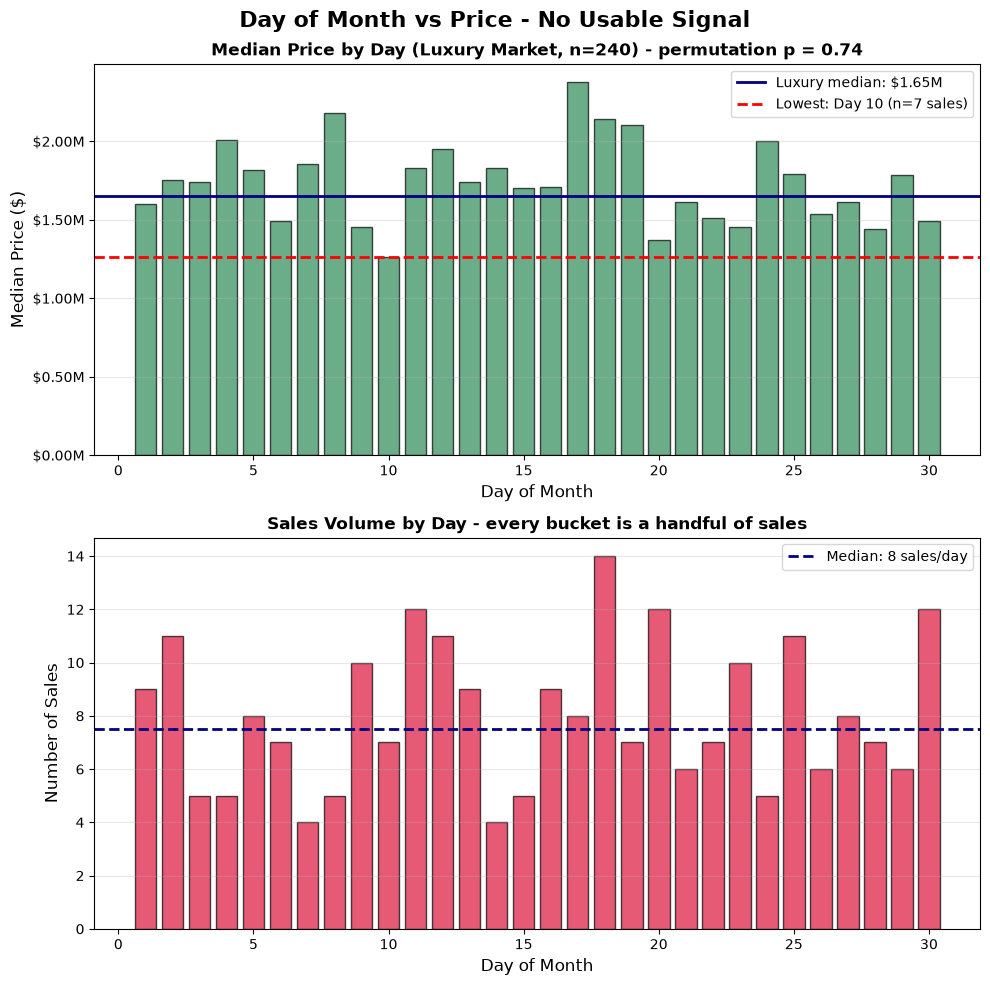


📊 BUYING-TIMING CONCLUSION:
   Lowest median price falls on day 10 ($1,260,000) - but from only 7 sales.
   Permutation test p = 0.742; whole-market rank of that day: 28/31.

   ❌ NO RECOMMENDATION. There is no mechanism by which the day of the month
      would move house prices, and the data does not show one either.
      Advising the client to 'buy on the 10th' would be selling her noise.


In [24]:
# Visualization: price and volume by day of month, with sample sizes made visible
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fig.suptitle('Day of Month vs Price - No Usable Signal', fontsize=16, fontweight='bold')

ax = axes[0]
ax.bar(daily_median_price['day_of_month'], daily_median_price['median_price'],
       color='seagreen', edgecolor='black', alpha=0.7)
ax.axhline(df_luxury_market['price'].median(), color='navy', linestyle='-', linewidth=2,
           label=f"Luxury median: ${df_luxury_market['price'].median()/1e6:.2f}M")
ax.axhline(best_day_price['median_price'], color='red', linestyle='--', linewidth=2,
           label=f"Lowest: Day {int(best_day_price['day_of_month'])} "
                 f"(n={int(best_day_price['n_sales'])} sales)")
ax.set_xlabel('Day of Month', fontsize=12)
ax.set_ylabel('Median Price ($)', fontsize=12)
ax.set_title(f'Median Price by Day (Luxury Market, n={len(df_luxury_market)}) - '
             f'permutation p = {p_day:.2f}', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.2f}M'))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
bars = ax.bar(daily_sales_volume['sale_day'], daily_sales_volume['sales_count'],
              color='crimson', edgecolor='black', alpha=0.7)
ax.axhline(daily_sales_volume['sales_count'].median(), color='navy', linestyle='--',
           linewidth=2, label=f"Median: {daily_sales_volume['sales_count'].median():.0f} sales/day")
ax.set_xlabel('Day of Month', fontsize=12)
ax.set_ylabel('Number of Sales', fontsize=12)
ax.set_title('Sales Volume by Day - every bucket is a handful of sales', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/best_day_to_buy_luxury_properties.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'images/best_day_to_buy_luxury_properties.png'")
plt.show()

print(f"\n📊 BUYING-TIMING CONCLUSION:")
print(f"   Lowest median price falls on day {int(best_day_price['day_of_month'])} "
      f"(${best_day_price['median_price']:,.0f}) - but from only "
      f"{int(best_day_price['n_sales'])} sales.")
print(f"   Permutation test p = {p_day:.3f}; whole-market rank of that day: {rank}/31.")
print(f"\n   ❌ NO RECOMMENDATION. There is no mechanism by which the day of the month")
print(f"      would move house prices, and the data does not show one either.")
print(f"      Advising the client to 'buy on the 10th' would be selling her noise.")

Next, the same question for the month of the year - this one at least has a
plausible mechanism behind it (seasonal buying patterns), so it deserves the same
test rather than dismissal.

In [25]:
df_luxury_market['sale_month'] = df_luxury_market['date'].dt.month

monthly_median_price = (df_luxury_market.groupby('sale_month')['price']
                        .agg(['median', 'size']).reset_index())
monthly_median_price.columns = ['month', 'median_price', 'n_sales']

month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_median_price['month_name'] = monthly_median_price['month'].map(month_map)

print("Median luxury sale price per month (with sample sizes):")
print(monthly_median_price[['month_name', 'median_price', 'n_sales']]
      .sort_values('median_price', ascending=False).to_string(index=False))

# Significance of the month effect, luxury segment and whole market
p_month, spread_month = permutation_pvalue(df_luxury_market['price'],
                                           df_luxury_market['sale_month'])
df_all['sale_month'] = df_all['date'].dt.month
p_month_all, _ = permutation_pvalue(df_all['price'], df_all['sale_month'])

best_month = monthly_median_price.loc[monthly_median_price['median_price'].idxmax()]
worst_month = monthly_median_price.loc[monthly_median_price['median_price'].idxmin()]
gap_luxury = (best_month['median_price'] - worst_month['median_price']) / worst_month['median_price'] * 100

all_month_median = df_all.groupby('sale_month')['price'].median()
gap_all = ((all_month_median[best_month['month']] - all_month_median[worst_month['month']])
           / all_month_median[worst_month['month']] * 100)

print(f"\nLuxury segment: {best_month['month_name']} vs {worst_month['month_name']} "
      f"= +{gap_luxury:.1f}% (n={int(best_month['n_sales'])} vs {int(worst_month['n_sales'])}), "
      f"permutation p = {p_month:.3f}")
print(f"Whole market:   the same two months differ by only +{gap_all:.1f}% "
      f"(permutation p = {p_month_all:.3f})")

# H7 as originally stated: do busier months have lower prices?
monthly_corr = monthly_median_price[['median_price', 'n_sales']].corr(method='spearman').iloc[0, 1]
print(f"\nH7 (volume vs price, monthly): Spearman rho = {monthly_corr:.3f} over "
      f"{len(monthly_median_price)} points - far too few to conclude anything.")

Median luxury sale price per month (with sample sizes):
month_name  median_price  n_sales
       Sep     2125000.0       18
       Nov     2090000.0       12
       Mar     1800000.0       21
       Oct     1750000.0       17
       Apr     1700000.0       19
       Dec     1700000.0       15
       Jan     1665000.0       16
       Feb     1650000.0       13
       Jun     1600000.0       32
       May     1525000.0       30
       Jul     1490000.0       19
       Aug     1485000.0       28



Luxury segment: Sep vs Aug = +43.1% (n=18 vs 28), permutation p = 0.435
Whole market:   the same two months differ by only +1.8% (permutation p = 0.000)

H7 (volume vs price, monthly): Spearman rho = -0.493 over 12 points - far too few to conclude anything.


And the corresponding visualization, with sample sizes shown so the reader can
judge the evidence rather than take the headline on trust:

✅ Executive dashboard saved as 'images/best_month_to_sell_luxury_properties.png'


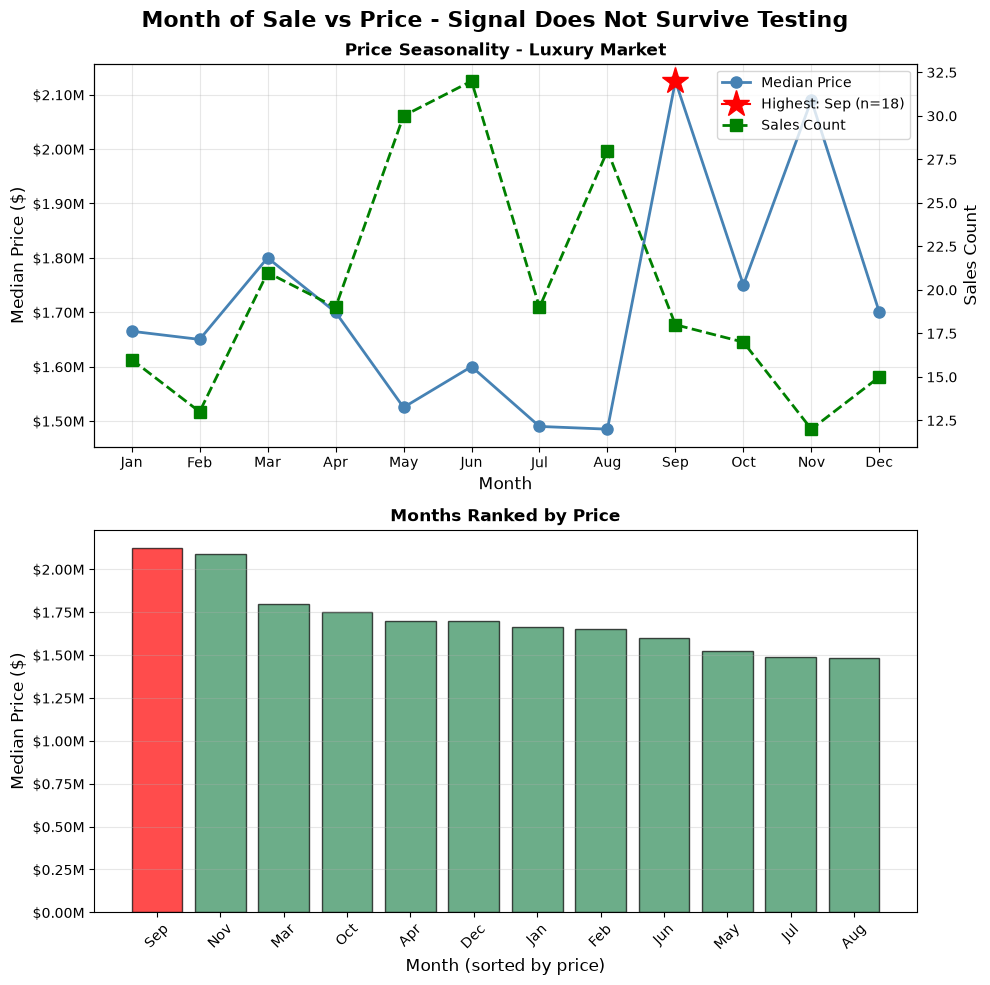


📊 SELLING-TIMING CONCLUSION:
   Highest median: Sep ($2,125,000, n=18)
   Lowest median:  Aug ($1,485,000, n=28)
   Gap in luxury segment: +43.1%   |   same gap market-wide: +1.8%
   Permutation test p = 0.435

   ❌ H6 REJECTED. H6 predicted a January peak; the observed peak is Sep,
      and within the luxury segment the gap does not survive a permutation
      test (p = 0.43) - a +43% swing on 18 sales is noise.

   Note the whole-market result: with ~90x more data the month effect IS
   statistically detectable (p = 0.000), but the same two months differ
   by only +1.8%. So mild seasonality is real - it is simply far too small
   to build a strategy on, and nothing like the +43% the small sample suggested.
   Statistical significance is not the same thing as a decision-relevant effect.


In [26]:
# Visualization: Best Month to Sell
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fig.suptitle('Month of Sale vs Price - Signal Does Not Survive Testing', fontsize=16, fontweight='bold')

# Top plot: Line plot showing price seasonality
ax = axes[0]
ax.plot(monthly_median_price['month'], monthly_median_price['median_price'],
        marker='o', linewidth=2, markersize=8, color='steelblue', label='Median Price')

# Highlight September
peak_price = best_month['median_price']
ax.plot(best_month['month'], peak_price, marker='*', markersize=20, color='red',
        label=f"Highest: {best_month['month_name']} (n={int(best_month['n_sales'])})", zorder=5)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Median Price ($)', fontsize=12)
ax.set_title('Price Seasonality - Luxury Market', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.2f}M'))
ax.legend()
ax.grid(True, alpha=0.3)

# Add sales count line (second y-axis)
df_luxury_market['sale_month'] = df_luxury_market['date'].dt.month

monthly_sales_volume = (
    df_luxury_market
    .groupby('sale_month')
    .size()
    .reset_index(name='sales_count')
)

ax2 = ax.twinx()
ax2.plot(monthly_sales_volume['sale_month'], monthly_sales_volume['sales_count'],
         marker='s', linewidth=2, markersize=8,
         color='green', linestyle='--', label='Sales Count')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Median Price ($)', fontsize=12)
ax2.set_ylabel('Sales Count', fontsize=12)

ax.set_title('Price Seasonality - Luxury Market', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.2f}M'))

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper right')

ax.grid(True, alpha=0.3)

# Bottom plot: Bar chart sorted by price
ax = axes[1]
monthly_sorted = monthly_median_price.sort_values('median_price', ascending=False)
colors = ['red' if month == best_month['month'] else 'seagreen' for month in monthly_sorted['month']]
bars = ax.bar(range(len(monthly_sorted)), monthly_sorted['median_price'],
               color=colors, edgecolor='black', alpha=0.7)
ax.set_xlabel('Month (sorted by price)', fontsize=12)
ax.set_ylabel('Median Price ($)', fontsize=12)
ax.set_title('Months Ranked by Price', fontweight='bold')
ax.set_xticks(range(len(monthly_sorted)))
ax.set_xticklabels(monthly_sorted['month_name'], rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.2f}M'))
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/best_month_to_sell_luxury_properties.png', dpi=300, bbox_inches='tight')
print("✅ Executive dashboard saved as 'images/best_month_to_sell_luxury_properties.png'")
plt.show()

# Summary
print(f"\n📊 SELLING-TIMING CONCLUSION:")
print(f"   Highest median: {best_month['month_name']} (${best_month['median_price']:,.0f}, "
      f"n={int(best_month['n_sales'])})")
print(f"   Lowest median:  {worst_month['month_name']} (${worst_month['median_price']:,.0f}, "
      f"n={int(worst_month['n_sales'])})")
print(f"   Gap in luxury segment: +{gap_luxury:.1f}%   |   same gap market-wide: +{gap_all:.1f}%")
print(f"   Permutation test p = {p_month:.3f}")
print(f"\n   ❌ H6 REJECTED. H6 predicted a January peak; the observed peak is "
      f"{best_month['month_name']},")
print(f"      and within the luxury segment the gap does not survive a permutation")
print(f"      test (p = {p_month:.2f}) - a +{gap_luxury:.0f}% swing on {int(best_month['n_sales'])} sales is noise.")
print(f"\n   Note the whole-market result: with ~90x more data the month effect IS")
print(f"   statistically detectable (p = {p_month_all:.3f}), but the same two months differ")
print(f"   by only +{gap_all:.1f}%. So mild seasonality is real - it is simply far too small")
print(f"   to build a strategy on, and nothing like the +{gap_luxury:.0f}% the small sample suggested.")
print(f"   Statistical significance is not the same thing as a decision-relevant effect.")


### Repeat sales - the direct test of the client's resale plan

Everything above measures *price levels*. The client's actual question is different:
if she buys now and sells within a year, does she make money? The dataset answers
that directly, because some properties appear **twice** - sold, then sold again
inside the observation window. Those repeat sales are the single most relevant
records in the file for this client, and my earlier analysis ignored them.

They also matter for data quality: duplicated `house_id` values are counted twice in
every median and correlation computed so far.

In [27]:
# Properties that transacted more than once inside the observation window
dupes = df_eda[df_eda['house_id'].duplicated(keep=False)].sort_values(['house_id', 'date'])
print(f"Houses sold more than once: {dupes['house_id'].nunique():,} "
      f"({len(dupes):,} rows - these are double-counted in every statistic above)")
print(f"Observation window: {df_eda['date'].min().date()} to {df_eda['date'].max().date()} "
      f"({(df_eda['date'].max() - df_eda['date'].min()).days} days)")

first, last = dupes.groupby('house_id').first(), dupes.groupby('house_id').last()
resale = pd.DataFrame({
    'buy_price': first['price'], 'sell_price': last['price'],
    'grade': first['grade'], 'zipcode': first['zipcode'],
    'hold_days': (last['date'] - first['date']).dt.days,
})
resale['return_pct'] = (resale['sell_price'] / resale['buy_price'] - 1) * 100

print(f"\nAll repeat sales (n={len(resale)}):")
print(f"  Median holding period: {resale['hold_days'].median():.0f} days")
print(f"  Median return:         {resale['return_pct'].median():+.1f}%")
print(f"  Median first price:    ${resale['buy_price'].median():,.0f}")

# The market-wide number is flattered by low-end flips. What matters is the
# client's own segment.
resale_luxury = resale[(resale['buy_price'] >= price_threshold) &
                       (resale['grade'] >= grade_threshold)]
print(f"\nRepeat sales in Jennifer's segment (price >= ${price_threshold:,.0f}, "
      f"grade >= {grade_threshold}), n={len(resale_luxury)}:")
if len(resale_luxury):
    print(resale_luxury[['buy_price', 'sell_price', 'hold_days', 'return_pct']]
          .sort_values('return_pct', ascending=False).to_string())
    print(f"\n  Median return in segment: {resale_luxury['return_pct'].median():+.1f}% "
          f"over {resale_luxury['hold_days'].median():.0f} days")
    print(f"  Typical round-trip transaction costs: 6-10% of sale price")
    print(f"\n  ⚠️  The median in-segment resale does NOT cover transaction costs.")

print(f"\n⚠️  Holding periods are capped by the observation window "
      f"({(df_eda['date'].max() - df_eda['date'].min()).days} days), so")
print(f"    'every property resold within a year' is a truncation artifact, not a finding.")

Houses sold more than once: 176 (353 rows - these are double-counted in every statistic above)
Observation window: 2014-05-02 to 2015-05-27 (390 days)

All repeat sales (n=176):
  Median holding period: 178 days
  Median return:         +54.4%
  Median first price:    $261,500

Repeat sales in Jennifer's segment (price >= $887,000, grade >= 10), n=5:
            buy_price  sell_price  hold_days  return_pct
house_id                                                
7856400300  1410000.0   1510000.0        263    7.092199
3528000040  1690000.0   1800000.0        176    6.508876
7856400240  1620000.0   1650000.0        229    1.851852
4139480200  1380000.0   1400000.0        174    1.449275
4139420590  1210000.0   1200000.0         99   -0.826446

  Median return in segment: +1.9% over 176 days
  Typical round-trip transaction costs: 6-10% of sale price

  ⚠️  The median in-segment resale does NOT cover transaction costs.

⚠️  Holding periods are capped by the observation window (390 days),

### Geographic insight - where the luxury market actually is

The client's brief is about *what* to buy; this is about *where*. Aggregating by
zipcode gives the geographic view the shortlist alone cannot - the shortlist is a
handful of houses, far too few to say which areas "dominate" anything.

Top 10 zipcodes by median sale price:
         median_price  median_ppsf  sales  waterfront_sales  median_grade
zipcode                                                                  
98039       1895000.0   565.165614     50                 1           9.0
98004       1150000.0   456.944444    317                 1           9.0
98040        993750.0   376.370822    282                12           9.0
98112        915000.0   424.242424    269                 0           8.0
98005        765475.0   316.340431    168                 0           8.0
98006        760184.5   288.232917    498                 4           9.0
98119        744975.0   416.652778    184                 0           8.0
98075        739999.0   250.830233    359                10           9.0
98109        736000.0   427.696078    109                 0           8.0
98102        710000.0   406.363771    104                 0           8.0

Zipcodes with the most luxury sales (pool n=240):
zipcode
98006    40
980


✅ Chart saved as 'images/geographic_price_distribution.png'


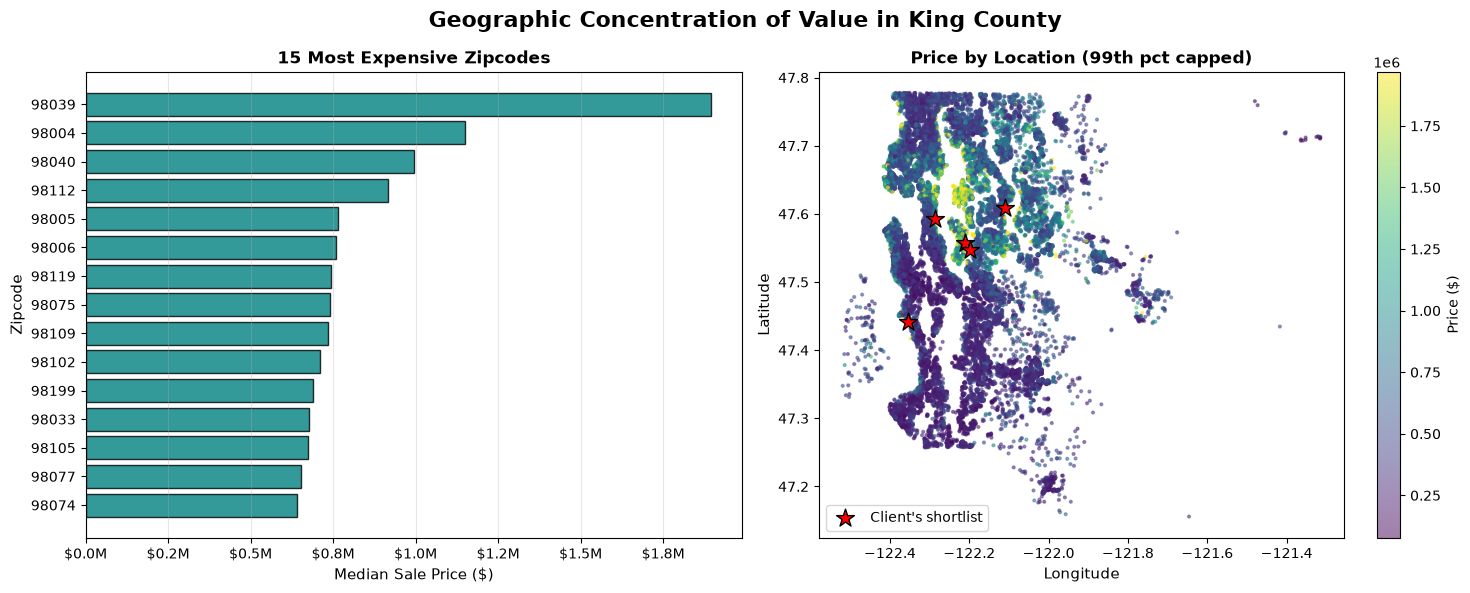


📍 GEOGRAPHIC INSIGHT:
   Most expensive zipcode: 98039 (median $1,895,000, 50 sales)
   Value concentrates along the Lake Washington / Mercer Island corridor -
   visible as the high-price band in the centre-east of the scatter plot.


In [28]:
zip_stats = (df_eda.groupby('zipcode')
             .agg(median_price=('price', 'median'),
                  median_ppsf=('price_per_sqft', 'median'),
                  sales=('price', 'size'),
                  waterfront_sales=('waterfront', 'sum'),
                  median_grade=('grade', 'median'))
             .sort_values('median_price', ascending=False))

print("Top 10 zipcodes by median sale price:")
print(zip_stats.head(10).to_string())

# Where the luxury pool actually concentrates - n=243, not n=5
luxury_by_zip = (df_luxury_market.groupby('zipcode').size()
                 .sort_values(ascending=False).head(10))
print(f"\nZipcodes with the most luxury sales (pool n={len(df_luxury_market)}):")
print(luxury_by_zip.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Geographic Concentration of Value in King County',
             fontsize=16, fontweight='bold')

ax = axes[0]
top15 = zip_stats.head(15).sort_values('median_price')
ax.barh(top15.index.astype(str), top15['median_price'], color='teal',
        edgecolor='black', alpha=0.8)
ax.set_xlabel('Median Sale Price ($)', fontsize=11)
ax.set_ylabel('Zipcode', fontsize=11)
ax.set_title('15 Most Expensive Zipcodes', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.grid(True, alpha=0.3, axis='x')

ax = axes[1]
sc = ax.scatter(df_eda['longitude'], df_eda['latitude'], c=df_eda['price'],
                cmap='viridis', s=4, alpha=0.5,
                vmax=df_eda['price'].quantile(0.99))
ax.scatter(df_jennifer_ranked['longitude'], df_jennifer_ranked['latitude'],
           color='red', s=180, marker='*', edgecolors='black', linewidths=1,
           label="Client's shortlist", zorder=5)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Price by Location (99th pct capped)', fontweight='bold')
plt.colorbar(sc, ax=ax, label='Price ($)')
ax.legend()

plt.tight_layout()
plt.savefig('images/geographic_price_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved as 'images/geographic_price_distribution.png'")
plt.show()

print(f"\n📍 GEOGRAPHIC INSIGHT:")
print(f"   Most expensive zipcode: {zip_stats.index[0]} "
      f"(median ${zip_stats['median_price'].iloc[0]:,.0f}, "
      f"{int(zip_stats['sales'].iloc[0])} sales)")
print(f"   Value concentrates along the Lake Washington / Mercer Island corridor -")
print(f"   visible as the high-price band in the centre-east of the scatter plot.")

# Step 9 - Final Result

### Recommendations for Jennifer Montgomery

#### 1) Properties matching the brief

Ranked by Premium Score, identified by `house_id` so they can actually be looked up:

| # | house_id | Zipcode | Price | Grade | View | Renovated |
|---|----------|---------|-------|-------|------|-----------|
| 1 | 1924059029 | 98040 (Mercer Island) | $4,670,000 | 12 | 4 | 2009 |
| 2 | 3625059152 | 98008 (Bellevue) | $3,300,000 | 11 | 4 | 1987 |
| 3 | 4114601570 | 98144 (Seattle) | $3,600,000 | 10 | 4 | 2002 |

Only a handful of properties satisfy every requirement simultaneously, and the exact
count depends on how unknown renovation years are treated (see the sensitivity check
in Step 8). **That scarcity is itself the finding**: the brief as stated is close to
unsatisfiable in this market, and the client should be told which requirement she
would most like to relax.

#### 2) What actually drives price - and what the client should pay for

- **Waterfront** is the single largest premium in the dataset: roughly **3x** the
  median non-waterfront price. It is worth paying for.
- **Renovation** carries a **+35%** premium market-wide and **+64%** in the luxury
  segment. This is the one hypothesis that survives a confounder check - the premium
  holds across every living-area band above 1,500 sqft.
- **Size and grade** dominate everything else (`sqft_living` r = 0.70, `grade` r = 0.67).
- **Large luxury homes offer better value per square foot** than small ones, so within
  her budget the client should buy square footage rather than address prestige alone.

#### 3) Timing - no recommendation, and that is the honest answer

Both timing hypotheses were tested and **rejected**:

- **H6 (month of sale):** predicted a January peak; the observed peak was September.
  Within the luxury segment the +43% gap does not survive a permutation test
  (p = 0.44) on 18 vs 28 sales. On the whole market a month effect *is* statistically
  detectable - but the same two months then differ by only **+1.8%**. Mild seasonality
  is real; it is far too small to time a purchase around, and nothing like +43%.
  Statistical significance is not the same as a decision-relevant effect.
- **H7 (day of month):** the "cheapest" day rests on a single-digit number of sales
  and reverses rank entirely on the full dataset. There is also no mechanism by which
  the day of the month would move house prices.

Recommending a purchase date on this evidence would be selling the client noise.

#### 4) The resale plan needs revisiting

The client wants to resell within a year. The repeat sales in this dataset - the most
direct evidence available - show a **median return of +1.9% over 176 days** within her
own price and grade segment (5 comparable transactions, ranging -0.8% to +7.1%). That does not cover the 6-10%
round-trip transaction costs of a property sale.

**Recommendation:** treat this as a purchase to hold, or revise the return
expectation. The market-wide repeat-sale figure looks far more attractive, but it
comes almost entirely from low-end renovation flips, which is a different business
from buying a $4M waterfront property.

#### 5) Geography

By median sale price the most expensive zipcodes are **98039 (Medina)**, **98004
(Bellevue)** and **98040 (Mercer Island)** - the Lake Washington corridor. Luxury
*transaction volume*, however, concentrates in **98006 (Bellevue)** and **98040**,
which is where the client will find the most choice. Note this corrects an earlier
draft of this analysis that claimed "98008 and 98040 dominate" - that was inferred
from a five-property shortlist rather than from the 240-sale luxury pool.

### Known limitations of this analysis

- `waterfront` imputation has low recall at a 0.7% base rate; it should not be trusted
  for individual properties, only in aggregate.
- Filling unknown renovation years with 0 removes qualifying candidates from an
  already tiny pool - both variants are reported.
- Repeat sales are double-counted in the market-wide medians and correlations.
- Defining "luxury" partly by price and then analysing prices within that group
  truncates the distribution.
- Single county, single 13-month window. Nothing here generalises further.

And also in the end I want to show the map with the best houses for Clien:

This specialized map highlights properties matching Jennifer's investment criteria:
- 🔵 **Blue markers**: Waterfront properties with high grades (≥10)
- ⭐ **Red markers**: Top 3 recommended properties for Jennifer

This map helps visualize where Jennifer should focus her property search.

In [29]:
# Create map
m = folium.Map(location=[47.6, -122.2], zoom_start=10, tiles='OpenStreetMap')

# # Add waterfront + high grade properties
print("Adding waterfront + high grade properties...")
waterfront_high = df_jennifer_ranked[(df_jennifer_ranked['waterfront'] == 1) & (df_jennifer_ranked['grade'] >= 10)]
for idx, row in waterfront_high.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"<b>Waterfront + High Grade</b><br>Price: ${row['price']:,.0f}<br>Grade: {row['grade']}<br>View: {row.get('view', 'N/A')}<br>Zip: {row['zipcode']}",
        icon=folium.Icon(color='blue', icon='home', prefix='fa')
    ).add_to(m)

# Highlight top 3 properties if available
try:
    print("Adding top 3 recommended properties...")
    top_3 = df_jennifer_ranked.head(3)
    for idx, row in top_3.iterrows():
        popup_text = f"<b>⭐ TOP RECOMMENDATION</b><br>Price: ${row['price']:,.0f}<br>Grade: {row['grade']}<br>Exclusivity: {row.get('premium_score', 'N/A'):.1f}<br>Zip: {row['zipcode']}"
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=popup_text,
            icon=folium.Icon(color='red', icon='home', prefix='fa')
        ).add_to(m)
except Exception as e:
    print(f"Note: Could not add top 5 recommendations ({e})")

folium.LayerControl().add_to(m)
m.save('interactive_map/map_jennifer_targets.html')
print("\n✅ Interactive map saved as 'interactive_map/map_jennifer_targets.html'")
print(f"   Waterfront + High Grade properties shown: {len(waterfront_high):,}")

# Display map
m

Adding waterfront + high grade properties...
Adding top 3 recommended properties...

✅ Interactive map saved as 'interactive_map/map_jennifer_targets.html'
   Waterfront + High Grade properties shown: 5


# THE END